In [1]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Compute cosine similarity matrix between all gradient results
import torch.nn.functional as F

In [2]:
def compute_cosine_similarity_matrix(results):
    """Compute pairwise cosine similarity matrix for gradient results."""
    n = len(results)
    cosine_sim_matrix = torch.zeros(n, n)

    # Compute cosine similarity for each pair (only upper triangle since it's symmetric)
    for i in range(n):
        for j in range(i, n):
            grad_i = results[i].gradient
            grad_j = results[j].gradient

            # Compute cosine similarity
            cos_sim = F.cosine_similarity(grad_i.unsqueeze(0),
                                          grad_j.unsqueeze(0)).item()

            # Fill both (i,j) and (j,i) since matrix is symmetric
            cosine_sim_matrix[i, j] = cos_sim
            cosine_sim_matrix[j, i] = cos_sim

    return cosine_sim_matrix


def compute_success(df_data,
                    threshold_angle=0.1,
                    consecutive_steps=100,
                    column_name=None):
    """
    Compute whether the pole is upright (straight) for consecutive_steps time points.
    
    Args:
        df_data: DataFrame with 'observations' column containing state arrays
        threshold_angle: Maximum angle deviation from vertical (in radians) to consider "straight"
        consecutive_steps: Number of consecutive steps required for success
    
    Returns:
        df_data: DataFrame with added 'success' column
    """
    success = []

    for idx in range(len(df_data)):
        observations = np.array(df_data['observations'].iloc[idx])

        # Extract cos and sin of pole angle (dimensions 1 and 2)
        cos_angle = observations[:, 1]
        sin_angle = observations[:, 2]

        # Compute actual angle from cos and sin
        angles = np.arctan2(sin_angle, cos_angle)

        # Check if angle is within threshold (close to 0, which is upright)
        is_straight = np.abs(angles) < threshold_angle

        # Check for consecutive_steps consecutive True values
        episode_success = False
        count = 0
        for straight in is_straight:
            if straight:
                count += 1
                if count >= consecutive_steps:
                    episode_success = True
                    break
            else:
                count = 0

        success.append(episode_success)
    column_name = column_name if column_name is not None else 'success'
    df_data[column_name] = np.array(success)
    return df_data

In [3]:
def load_data(
    df_metadata,
    cart_position=None,
    pole_angle=None,
    normalization_method=None,
    seed=None,
):
    """
    Load intervention data from directories matching the specified criteria.
    
    Parameters can be single values or lists. If a parameter is None, it matches all values.
    
    Returns:
        pd.DataFrame: DataFrame with config info and episode data
    """

    # Convert single values to lists for uniform handling
    def to_list(val):
        if val is None:
            return None
        return val if isinstance(val, list) else [val]

    cart_position_list = to_list(cart_position)
    pole_angle_list = to_list(pole_angle)
    seed_list = to_list(seed)
    normalization_list = to_list(normalization_method)

    # Filter configs based on criteria
    filtered_configs = []
    for idx, config in df_metadata.iterrows():
        inital_state = config.get('initial_state')
        # Check each criterion
        if cart_position_list is not None and inital_state[
                0] not in cart_position_list:
            continue
        if pole_angle_list is not None and inital_state[
                1] not in pole_angle_list:
            continue
        if normalization_list is not None and config.get(
                'normalization_method') not in normalization_list:
            continue
        if seed_list is not None and config.get('config_seed') not in seed_list:
            continue

        filtered_configs.append(config)

    print(f"Found {len(filtered_configs)} configurations")
    # Load episode data for each matching config
    results = []
    for config in tqdm(filtered_configs):
        directory = Path(config['directory'])
        episode_path = directory / "activations" / "episode_0000.pkl"

        if episode_path.exists():
            # Load the pickled episode data
            with open(episode_path, 'rb') as f:
                episode_data = pickle.load(f)

            # Unflatten the data structure
            episode_data = episode_data['data']
            for key, value in episode_data.items():

                if key == 'latent_states':
                    config[key] = value.squeeze()
                else:
                    config[key] = value

            results.append(config)

    return pd.DataFrame(results)


def flatten_dict(d, parent_key='', sep='_'):
    """
    Flatten a nested dictionary.
    
    Args:
        d: Dictionary to flatten
        parent_key: String to prepend to keys
        sep: Separator between nested keys
    
    Returns:
        Flattened dictionary
    """
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


In [4]:
sweep_base_dir = Path("logs/25-12-03-spsa-position")

all_metadata = []
for sweep_dir in sweep_base_dir.iterdir():
    if sweep_dir.is_dir():
        metadata_path = sweep_dir / "activations" / "episode_0000_metadata.json"
        if metadata_path.exists():
            with open(metadata_path, 'r') as f:
                try:
                    metadata = json.load(f)
                    # Flatten the nested metadata dictionary
                    flattened_metadata = flatten_dict(metadata)
                    # Add the directory path
                    flattened_metadata['directory'] = str(sweep_dir)
                    all_metadata.append(flattened_metadata)
                except json.JSONDecodeError:
                    print(f"Error decoding JSON for {metadata_path}")
                    continue

print(f"Found {len(all_metadata)} configurations")
# Create DataFrame from flattened metadata

df_metadata = pd.DataFrame(all_metadata)


Found 1408 configurations


In [5]:
df_metadata.head()

,config_type,config_location,config_magnitude,config_seed,config_eps,config_horizon,config_random,config_direction,config_hinge_1_value,config_normalization_method,config_start_step,config_end_step,checkpoint,episode_idx,episode_length,total_reward,timestamp,task,obs_type,directory
0,directional_addition,encoder_output,-5.0,6,0.0001,5,True,"[-8.77537189724085e-05, 0.0006485261886801559,...",0.0,None,0,None,/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpo...,0,500,969.257975,2025-12-03T20:52:21.819787,cartpole-swingup,state,logs/25-12-03-spsa-position/20251203_205207
1,directional_addition,encoder_output,-5.0,4,0.0100,5,False,"[4.254512987245107e-06, 1.546025123388972e-05,...",0.0,None,0,None,/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpo...,0,500,906.472519,2025-12-03T21:03:28.596779,cartpole-swingup,state,logs/25-12-03-spsa-position/20251203_210314
2,directional_addition,encoder_output,-1.0,3,0.0001,10,True,"[0.019558155463318225, 0.0014192951112336014, ...",0.0,None,0,None,/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpo...,0,500,996.979791,2025-12-03T21:48:37.297113,cartpole-swingup,state,logs/25-12-03-spsa-position/20251203_214823
3,directional_addition,encoder_output,0.0,7,0.0100,30,True,"[-0.0026794305696573773, -0.005151457739344032...",0.0,None,0,None,/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpo...,0,500,999.762237,2025-12-03T22:28:30.307633,cartpole-swingup,state,logs/25-12-03-spsa-position/20251203_222816
4,directional_addition,encoder_output,-2.5,0,0.0100,10,False,"[0.0002306871028849855, -0.0002113052323693409...",0.0,None,0,None,/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpo...,0,500,990.285147,2025-12-03T21:37:02.673129,cartpole-swingup,state,logs/25-12-03-spsa-position/20251203_213648


In [6]:
df = load_data(
    df_metadata,
    cart_position=None,
    pole_angle=None,
    seed=None,
)

Found 1408 configurations


  0%|          | 0/1408 [00:00<?, ?it/s]

100%|██████████| 1408/1408 [00:08<00:00, 164.17it/s]


In [7]:
dim_names = {
    0: 'Cart Position',
    1: 'cos(Pole Angle)',
    2: 'sin(Pole Angle)',
    3: 'Cart Velocity',
    4: 'Pole Angular Velocity',
}

In [8]:
df = compute_success(df)

In [9]:
df['config_hinge_1_value_degrees'] = np.degrees(df['config_hinge_1_value'])
df['hinge_str'] = df['config_hinge_1_value_degrees'].round(0).astype(str)

for dim in range(5):
    df[f'average_dim_{dim}'] = df['observations'].apply(
        lambda x: np.mean(np.array(x)[:, dim]))

In [10]:
df['total_position_change'] = df['observations'].apply(
    lambda x: np.array(x)[-1, 0] - np.array(x)[0, 0])

In [ ]:
df['cumulative_abs_position_change'] = df['observations'].apply(
    lambda x: np.sum(np.abs(np.diff(np.array(x)[:, 0]))))

df['cumulative_abs_position_change'] = df['observations'].apply(
    lambda x: np.sum(np.abs(np.diff(np.array(x)[:, 0]))))

df['cumulative_position_change'] = df['observations'].apply(
    lambda x: np.sum(np.diff(np.array(x)[:, 0])))

In [12]:
df_spsa = df[df['config_random'] == False]
df_random = df[df['config_random'] == True]

## General overview

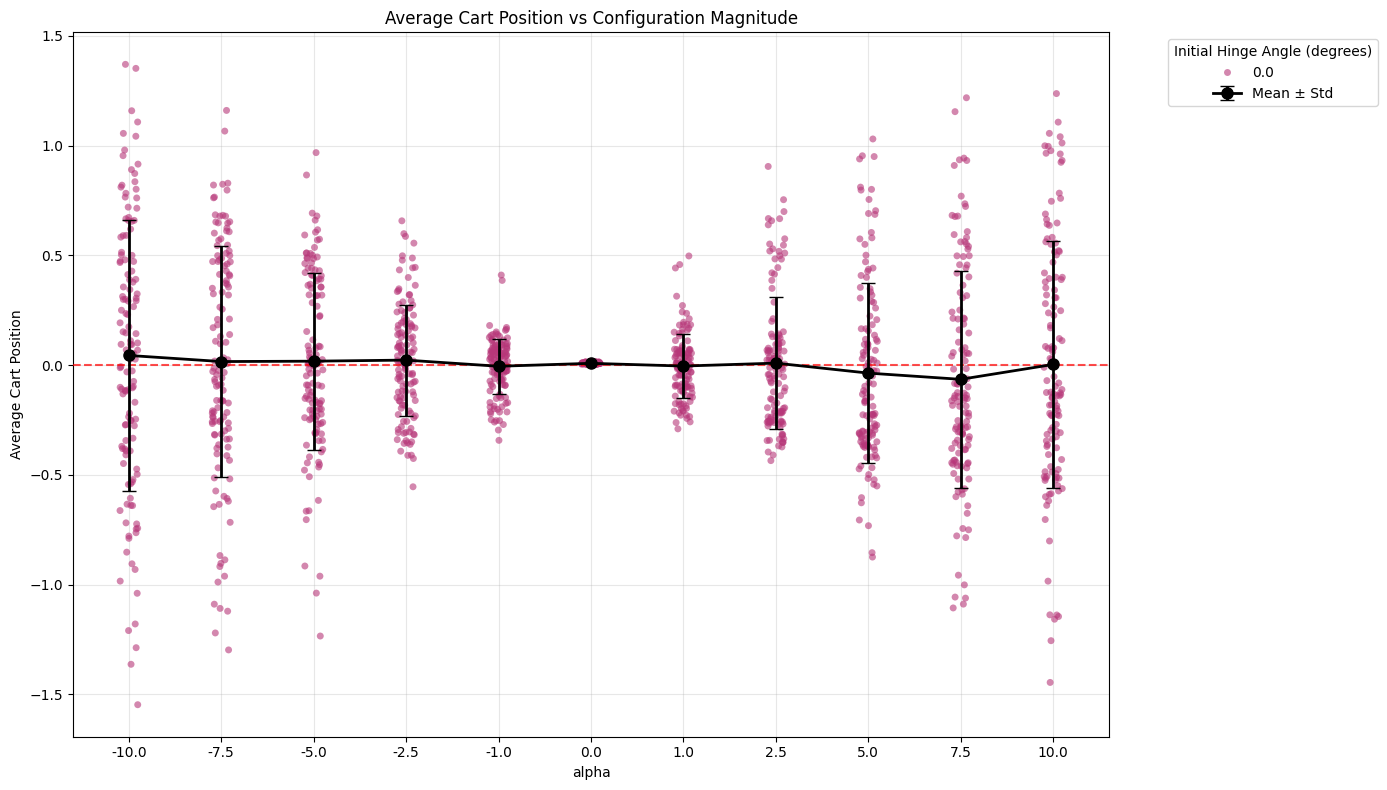

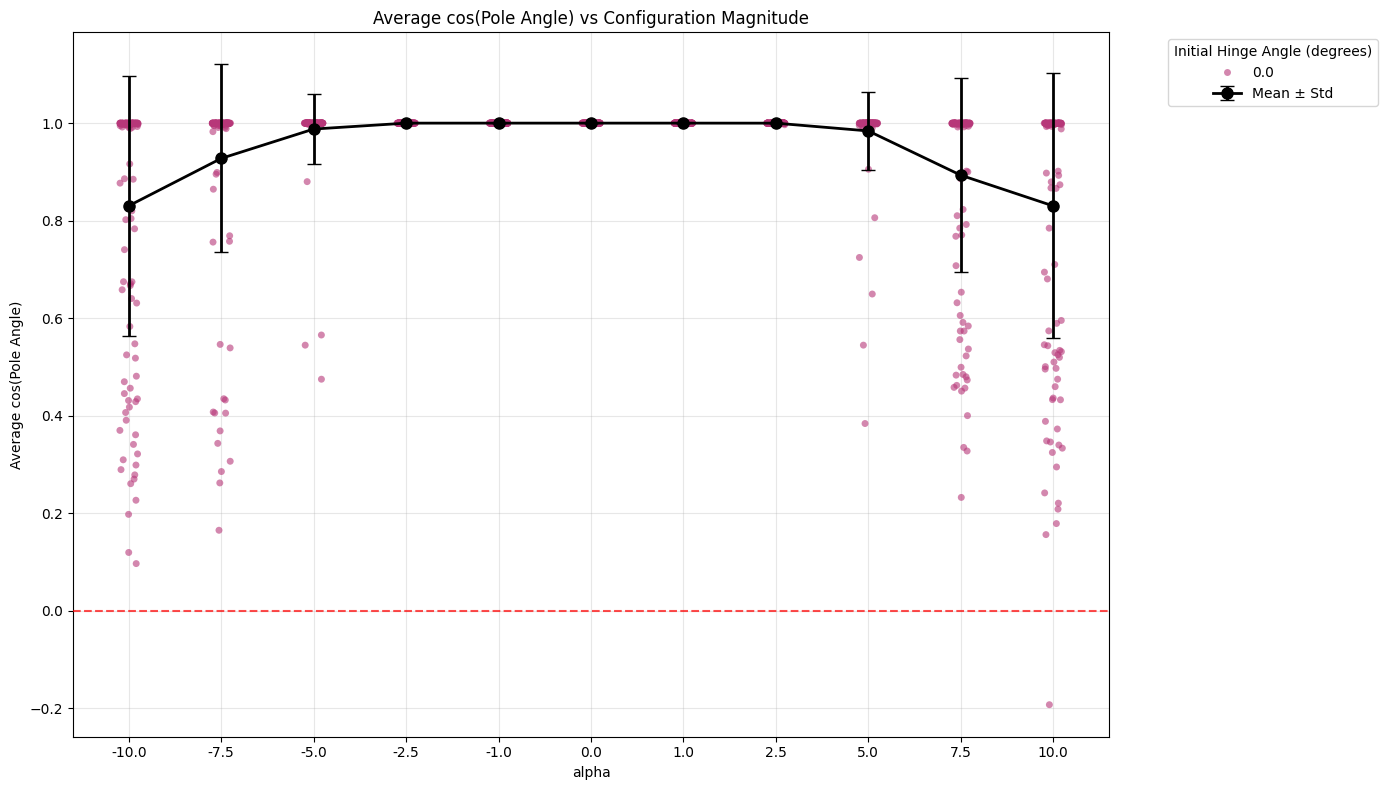

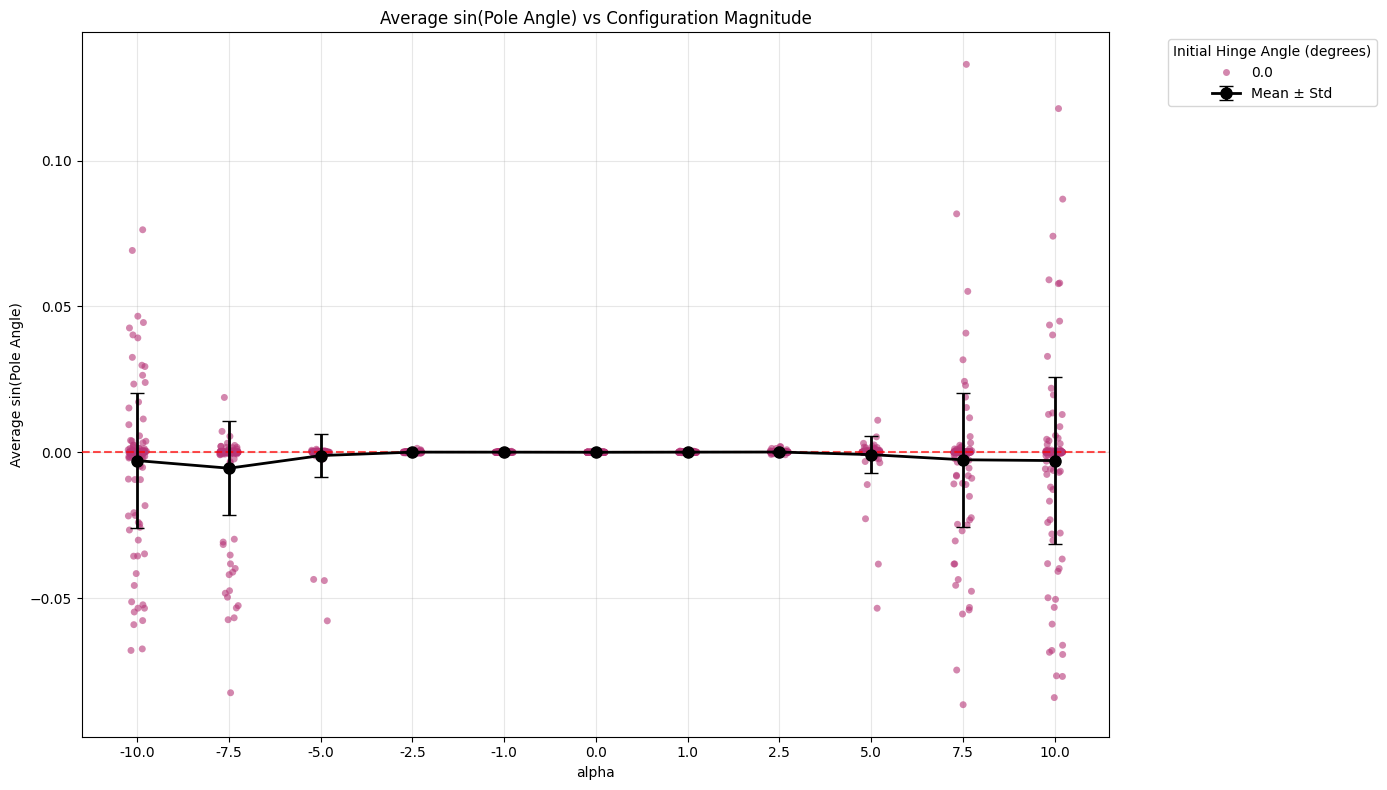

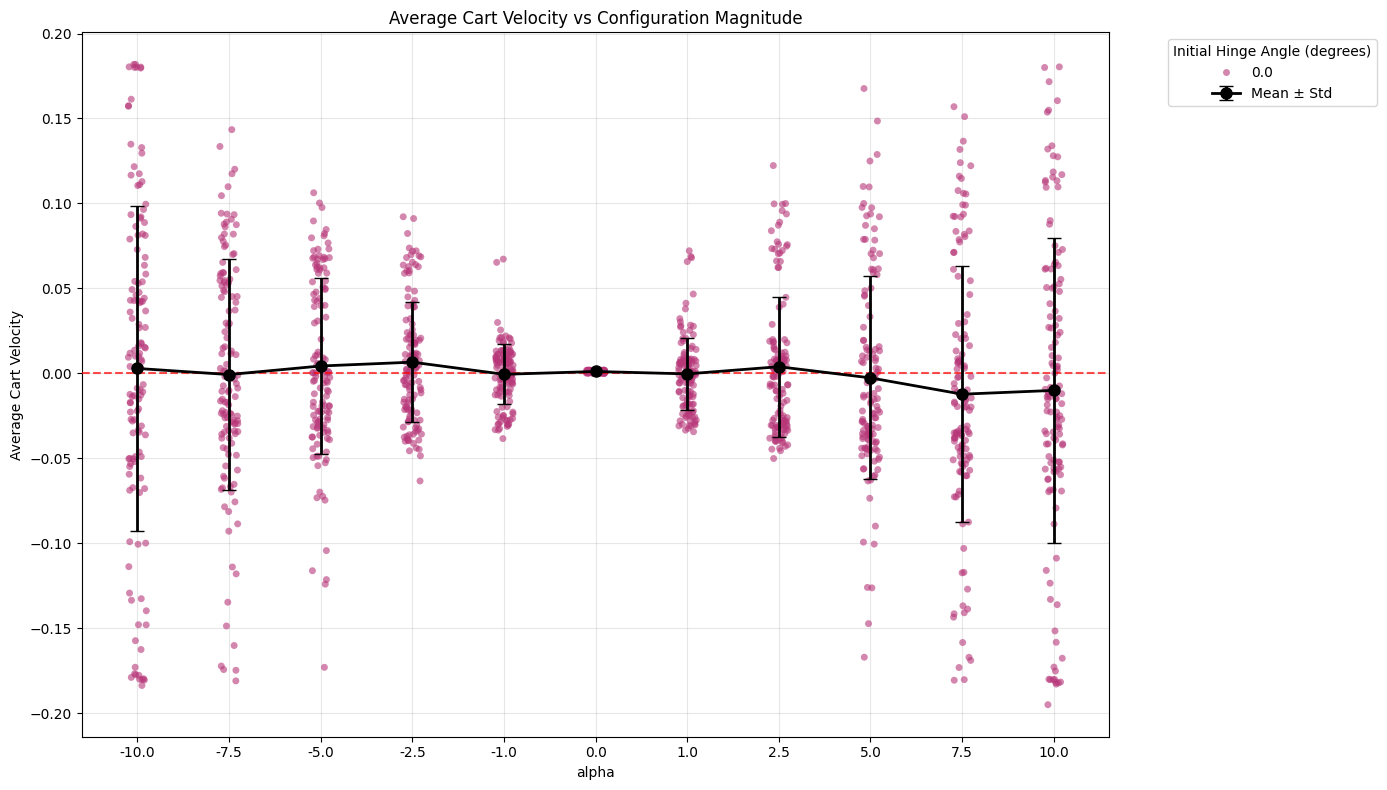

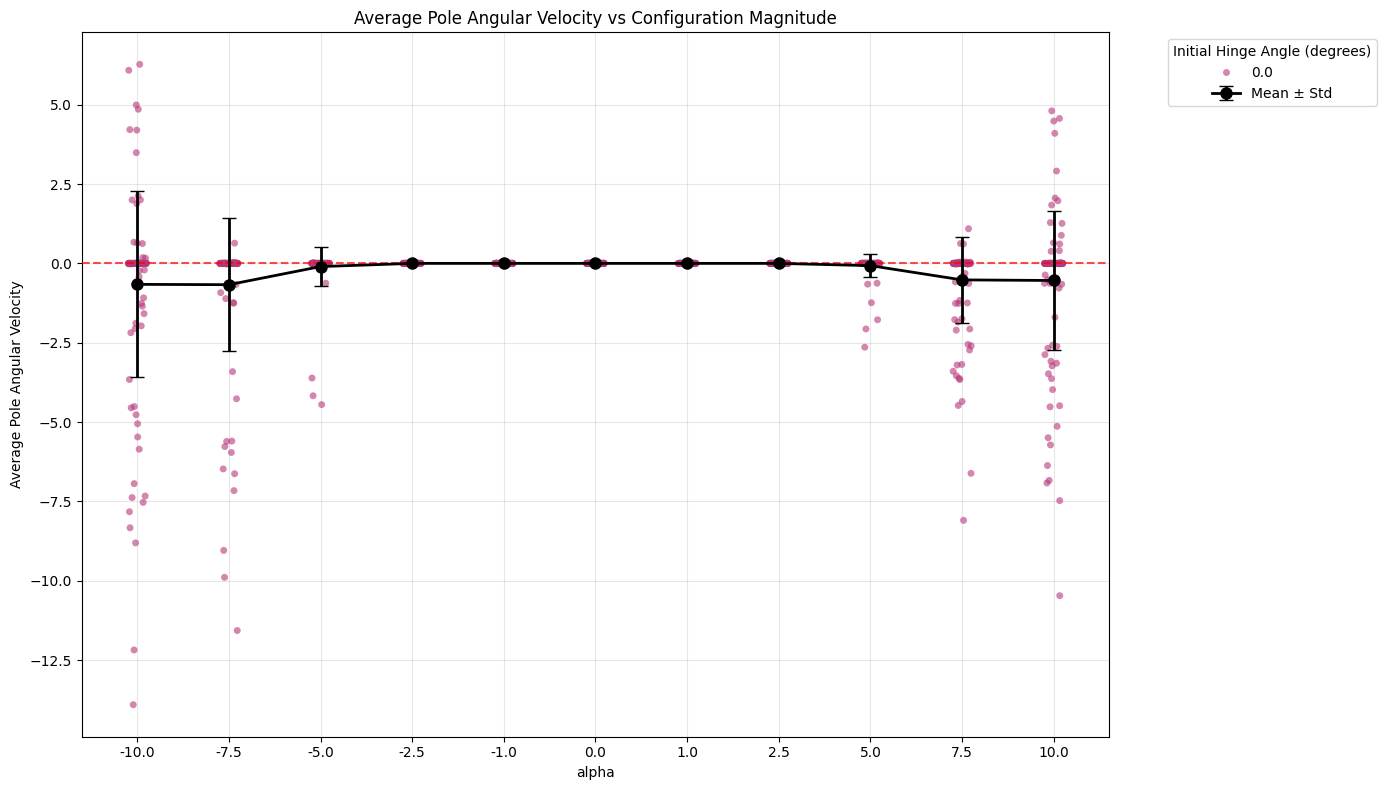

In [13]:
for dim in range(5):
    plt.figure(figsize=(14, 8))
    sns.stripplot(data=df,
                  x='config_magnitude',
                  y=f'average_dim_{dim}',
                  hue='hinge_str',
                  hue_order=sorted(df['hinge_str'].unique(),
                                   key=lambda x: float(x)),
                  alpha=0.6,
                  palette='magma')

    # Calculate mean and std per config_magnitude
    grouped = df.groupby('config_magnitude')[f'average_dim_{dim}'].agg(
        ['mean', 'std'])
    x_positions = range(len(grouped))
    magnitudes = grouped.index

    # Plot mean with error bars
    plt.errorbar(x_positions,
                 grouped['mean'],
                 yerr=grouped['std'],
                 fmt='-o',
                 color='black',
                 markersize=8,
                 capsize=5,
                 linewidth=2,
                 label='Mean ± Std',
                 zorder=10)

    # Add horizontal line at y=0
    plt.axhline(y=0,
                color='red',
                linestyle='--',
                linewidth=1.5,
                alpha=0.7,
                zorder=5)

    plt.xlabel('alpha')
    plt.ylabel(f'Average {dim_names[dim]}')
    plt.title(f'Average {dim_names[dim]} vs Configuration Magnitude')
    plt.grid(True, alpha=0.3)
    plt.legend(title='Initial Hinge Angle (degrees)',
               bbox_to_anchor=(1.05, 1),
               loc='upper left')
    plt.tight_layout()
    plt.show()

## SPSA vs Random

In [18]:
df_spsa.columns

Index(['config_type', 'config_location', 'config_magnitude', 'config_seed',
       'config_eps', 'config_horizon', 'config_random', 'config_direction',
       'config_hinge_1_value', 'config_normalization_method',
       'config_start_step', 'config_end_step', 'checkpoint', 'episode_idx',
       'episode_length', 'total_reward', 'timestamp', 'task', 'obs_type',
       'directory', 'observations', 'actions', 'rewards', 'dones',
       'latent_states', 'timesteps', 'success', 'config_hinge_1_value_degrees',
       'hinge_str', 'average_dim_0', 'average_dim_1', 'average_dim_2',
       'average_dim_3', 'average_dim_4', 'total_position_change',
       'cumulative_abs_position_change', 'cumulative_position_change'],
      dtype='object')

In [20]:
df_random_1e2

,config_type,config_location,config_magnitude,config_seed,config_eps,config_horizon,config_random,config_direction,config_hinge_1_value,config_normalization_method,...,config_hinge_1_value_degrees,hinge_str,average_dim_0,average_dim_1,average_dim_2,average_dim_3,average_dim_4,total_position_change,cumulative_abs_position_change,cumulative_position_change


In [25]:
df_spsa['config_eps'] == 1e-2

1        True
4        True
5       False
6        True
7        True
        ...  
1391     True
1394    False
1396     True
1403     True
1405    False
Name: config_eps, Length: 704, dtype: bool

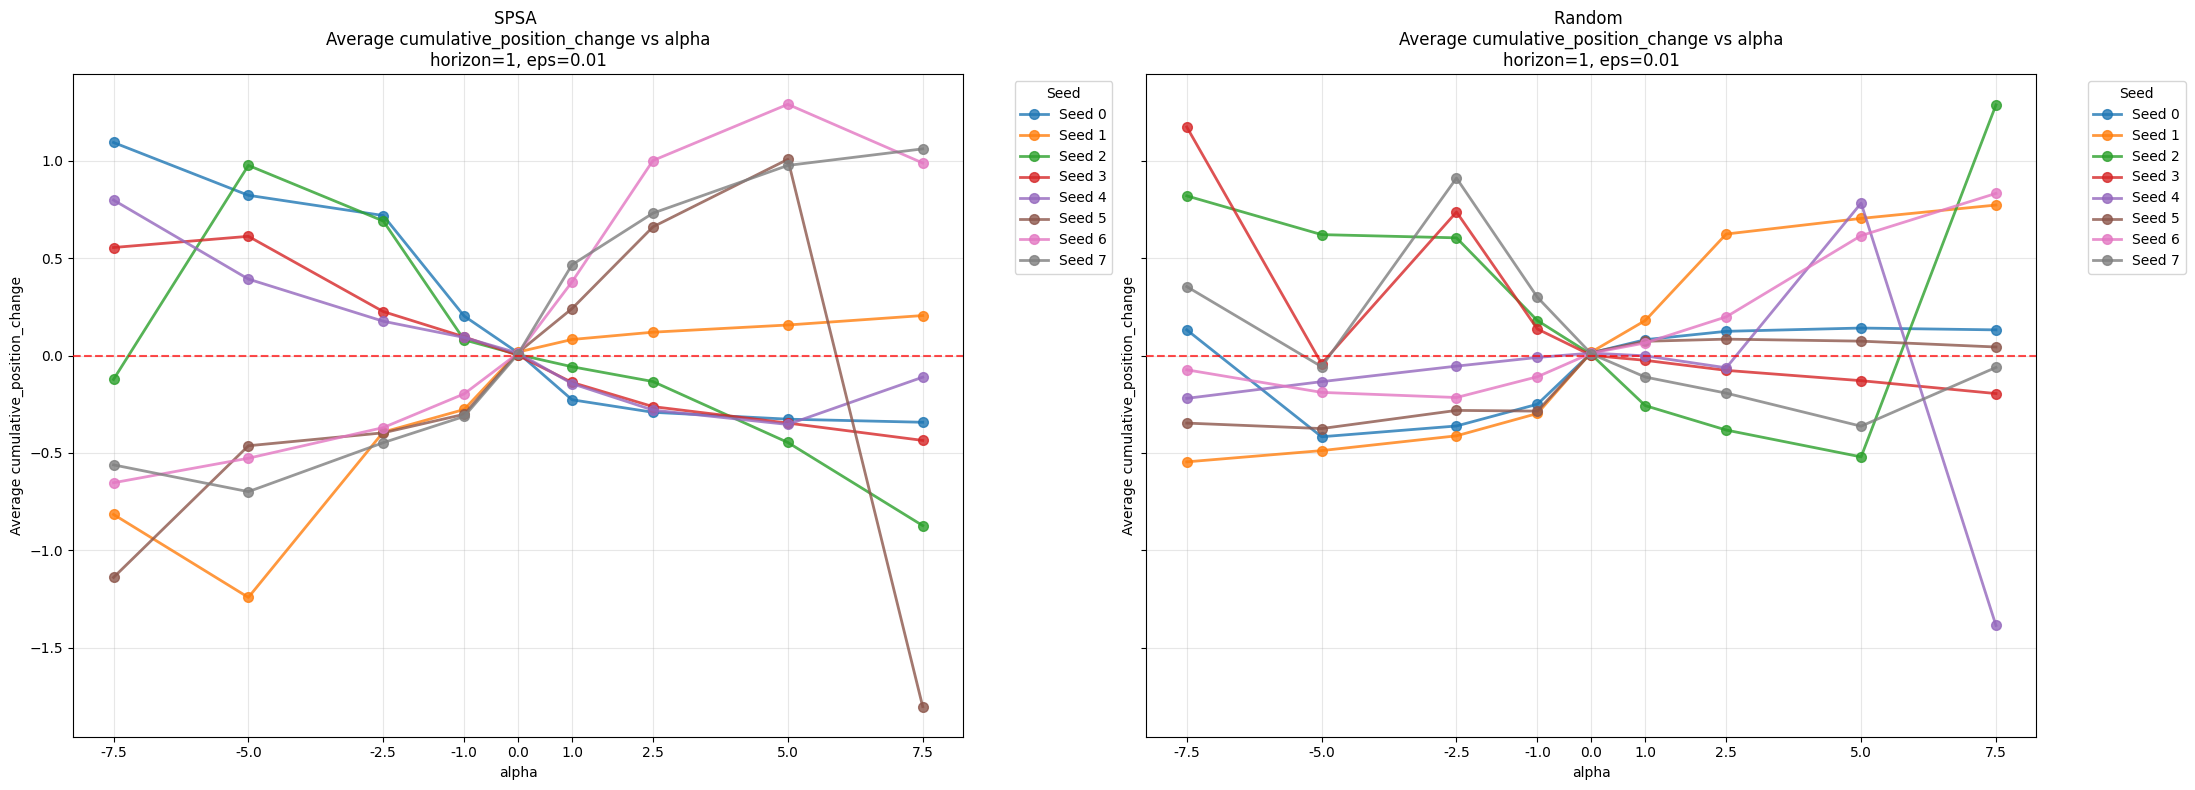

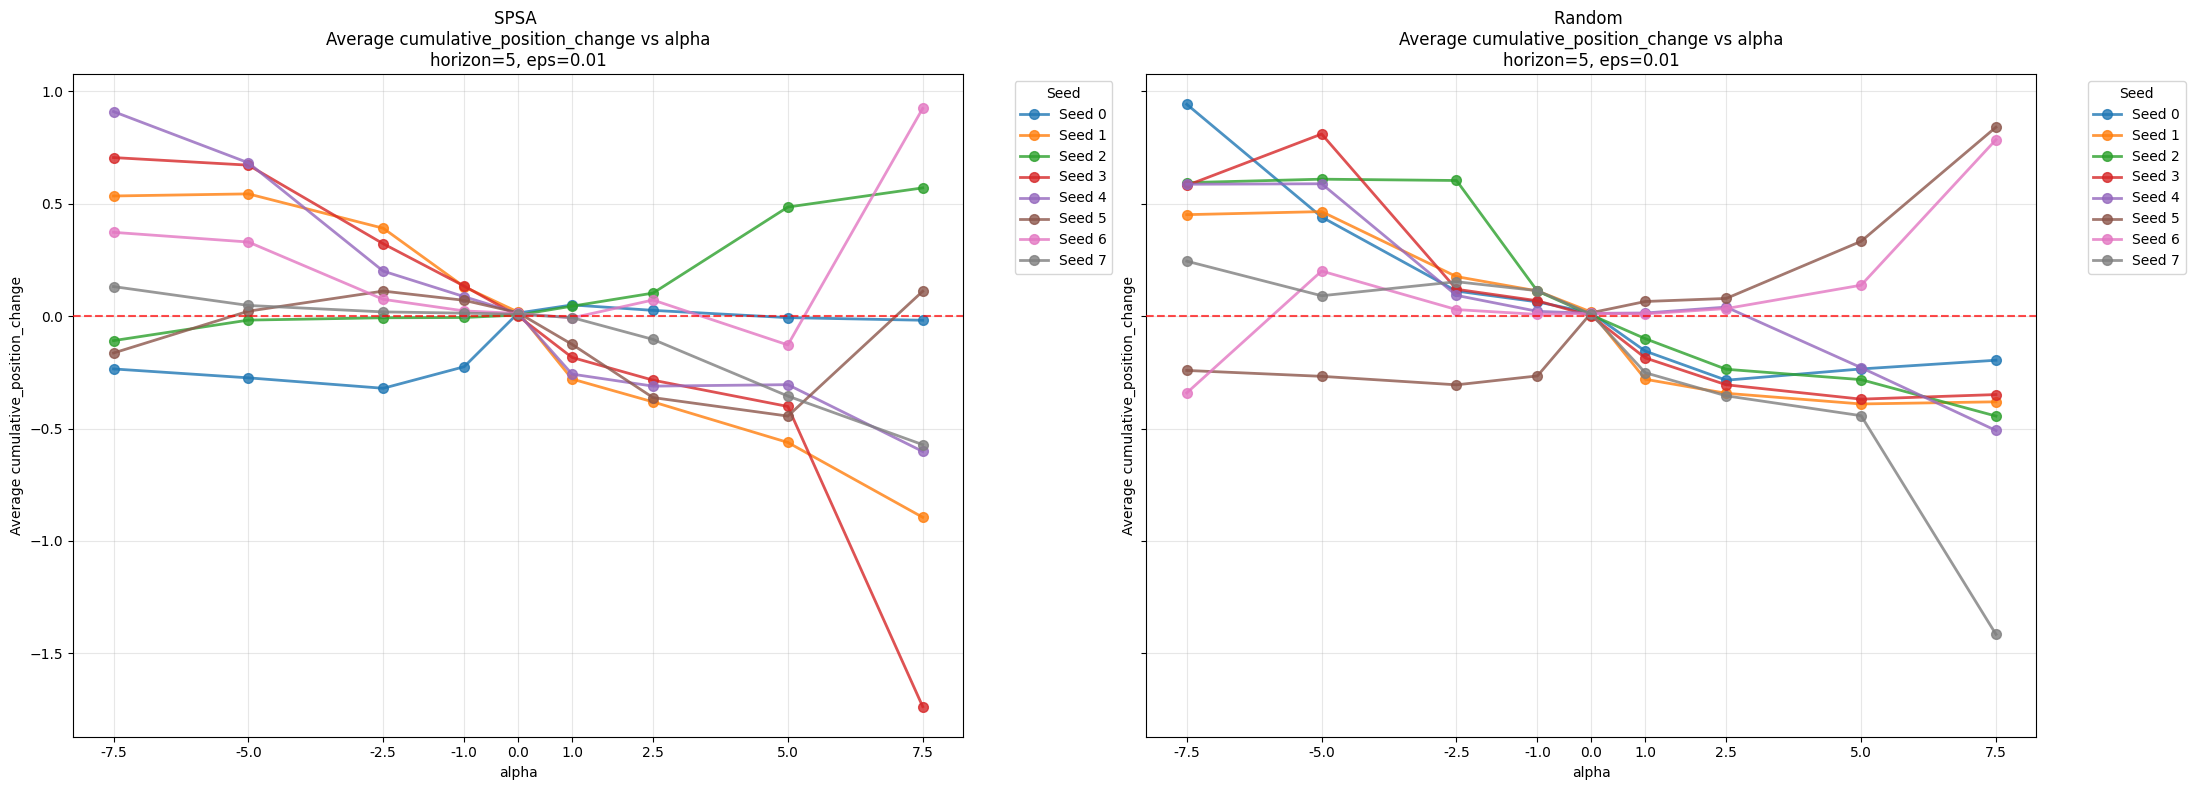

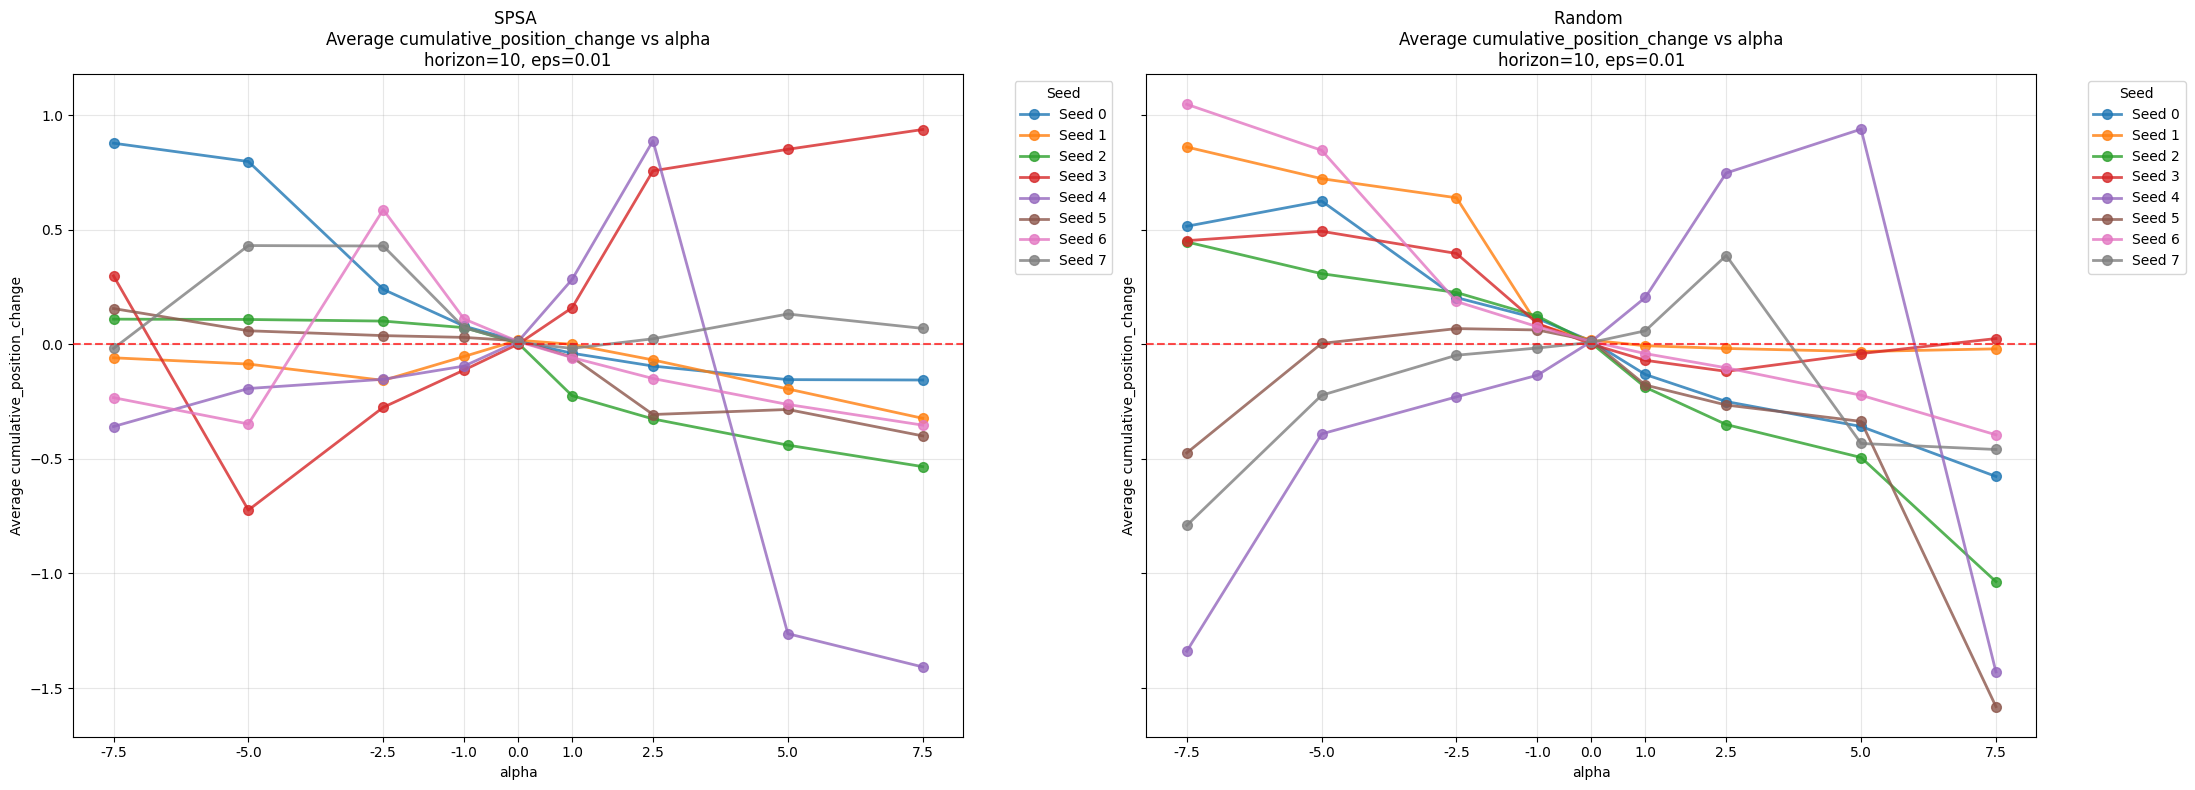

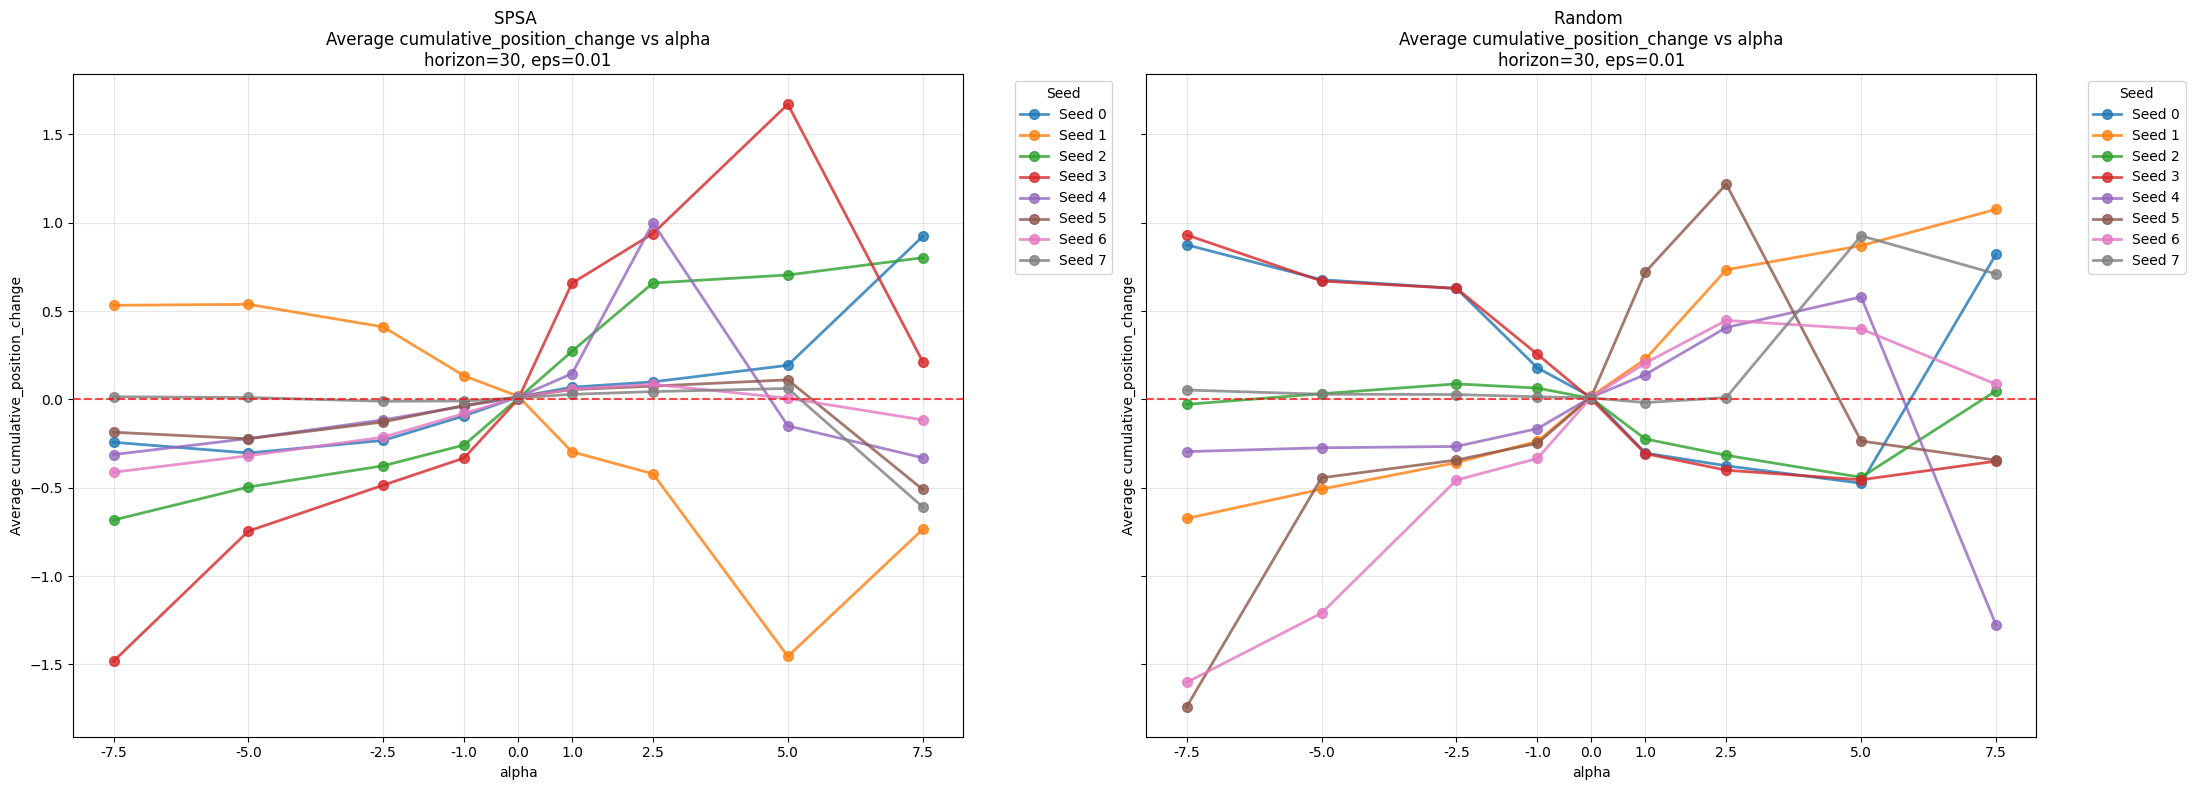

In [ ]:
4  # Only consider epsilon 1e-2, by filtering the DataFrames accordingly
epsilon_value = 1e-2
df_spsa_1e2 = df_spsa[df_spsa["config_eps"] == epsilon_value]
df_random_1e2 = df_random[df_random["config_eps"] == epsilon_value]

# Remove config_magnitude -10 and 10 from both dataframes
df_spsa_1e2 = df_spsa_1e2[~df_spsa_1e2["config_magnitude"].isin([-10.0, 10.0])]
df_random_1e2 = df_random_1e2[~df_random_1e2["config_magnitude"].
                              isin([-10.0, 10.0])]

# Collect all unique horizons present for this epsilon in both method DataFrames
horizons = sorted(set(df_spsa_1e2["config_horizon"].unique()).union(
    df_random_1e2["config_horizon"].unique()),
                  key=lambda x: float(x))

#variable_to_plot = 'total_position_change'
#variable_to_plot = 'average_dim_0'
variable_to_plot = 'cumulative_position_change'
for dim in range(1):
    for horizon in horizons:
        fig, axes = plt.subplots(1, 2, figsize=(22, 8), sharey=True)
        plot_data = {
            "SPSA ":
                df_spsa_1e2[df_spsa_1e2["config_horizon"] == horizon],
            "Random ":
                df_random_1e2[df_random_1e2["config_horizon"] == horizon],
        }
        for ax, (label, subset) in zip(axes, plot_data.items()):
            # Find all unique config_magnitude values that’ll ever appear, for correct ticks
            all_mags = sorted(
                set(df_spsa_1e2["config_magnitude"].unique()).union(
                    df_random_1e2["config_magnitude"].unique()))
            # Plot one line per seed
            for seed in sorted(subset["config_seed"].unique()):
                seed_df = subset[subset["config_seed"] == seed]
                grouped = seed_df.groupby(
                    'config_magnitude')[variable_to_plot].mean()
                ax.plot(grouped.index,
                        grouped.values,
                        '-o',
                        label=f'Seed {seed}',
                        alpha=0.8,
                        markersize=7,
                        linewidth=2)
            # Set correct x-ticks and labels
            ax.set_xticks(all_mags)
            ax.set_xticklabels([str(x) for x in all_mags])
            # Add horizontal line at y=0
            ax.axhline(
                y=0,
                color='red',
                linestyle='--',
                linewidth=1.5,
                alpha=0.7,
                zorder=5,
            )

            ax.set_xlabel('alpha')
            ax.set_ylabel(f'Average {variable_to_plot}')
            ax.set_title(
                f'{label}\nAverage {variable_to_plot} vs alpha\nhorizon={horizon}, eps={epsilon_value}'
            )
            ax.grid(True, alpha=0.3)
            ax.legend(title='Seed', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

In [ ]:
for dim in range(1):
    fig, axes = plt.subplots(1, 2, figsize=(22, 8), sharey=True)
    plot_data = {"SPSA ": df_spsa, "Random ": df_random}
    for ax, (label, subset) in zip(axes, plot_data.items()):
        sns.stripplot(
            data=subset,
            x='config_magnitude',
            y=f'average_dim_{dim}',
            hue='config_seed',
            #hue_order='seed',
            alpha=0.6,
            palette='magma',
            ax=ax,
        )

        # Calculate mean and std per config_magnitude
        grouped = subset.groupby('config_magnitude')[f'average_dim_{dim}'].agg(
            ['mean', 'std'])
        x_positions = range(len(grouped))
        magnitudes = grouped.index

        # Plot mean without error bars
        ax.plot(
            x_positions,
            grouped['mean'],
            '-o',
            color='black',
            markersize=8,
            linewidth=2,
            label='Mean',
            zorder=10,
        )

        # Add horizontal line at y=0
        ax.axhline(
            y=0,
            color='red',
            linestyle='--',
            linewidth=1.5,
            alpha=0.7,
            zorder=5,
        )

        ax.set_xlabel('alpha')
        ax.set_ylabel(f'Average {dim_names[dim]}')
        ax.set_title(f'{label}\nAverage {dim_names[dim]} vs alpha')
        ax.grid(True, alpha=0.3)
        ax.legend(title='Initial Hinge Angle (degrees)',
                  bbox_to_anchor=(1.05, 1),
                  loc='upper left')
    plt.tight_layout()
    plt.show()

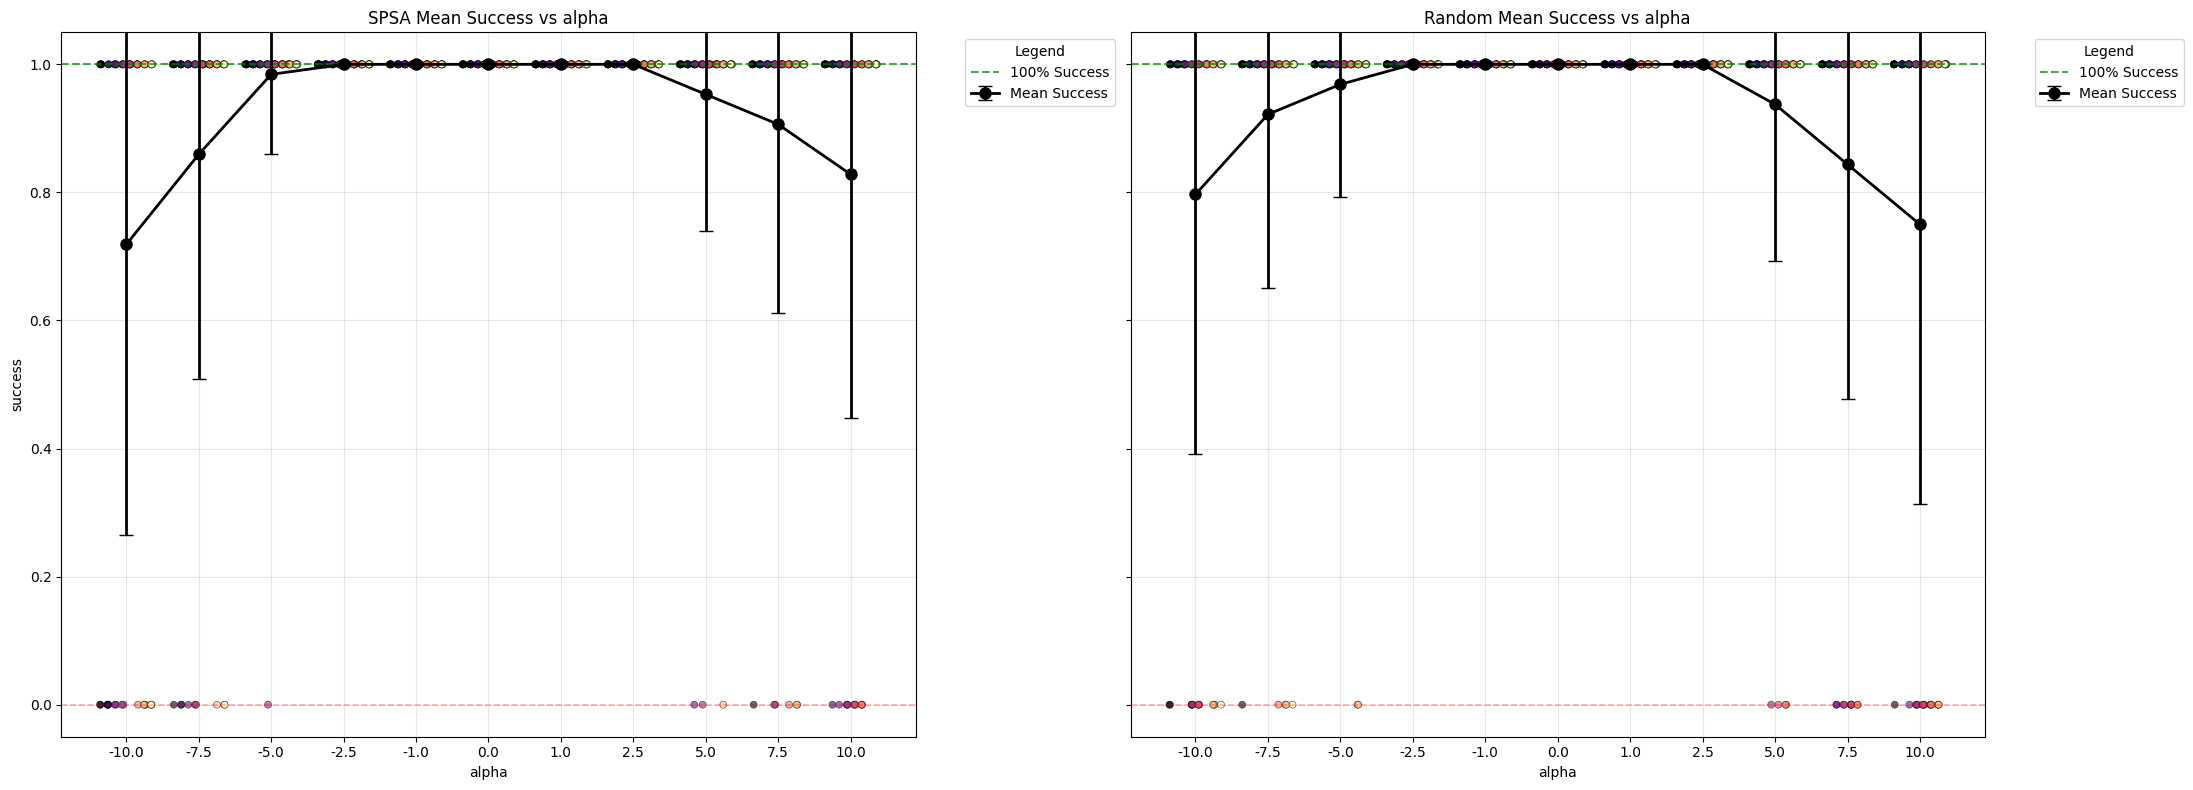

In [79]:
# Compute mean "success" on y, x axis = config_magnitude, separate plots for SPSA and Random

# Define what "success" is. Let's define success as total_reward >= 990.
# You may want to adjust this threshold to match your actual max/optimal rewards.
#SUCCESS_THRESHOLD = 990

fig, axes = plt.subplots(1, 2, figsize=(22, 8), sharey=True)
plot_data = {"SPSA": df_spsa, "Random": df_random}

for ax, (label, subset) in zip(axes, plot_data.items()):
    # Compute a success column: 1 if success, 0 if not
    subset = subset.copy()

    # Group by config_magnitude and get mean and std of success rate
    grouped = subset.groupby('config_magnitude')['success'].agg(
        ['mean', 'std', 'count'])
    x_positions = np.arange(len(grouped))
    x_labels = grouped.index

    # Plot success rate scatter per seed across config_magnitude for visualization (optional)
    # We'll force the scatter (stripplot) to x positions that match errorbar
    # so both align visually.
    # To do this, map config_magnitude values to x positions.
    magnitude_to_pos = {v: i for i, v in enumerate(x_labels)}
    subset['_x_pos'] = subset['config_magnitude'].map(magnitude_to_pos)

    sns.stripplot(data=subset,
                  x='_x_pos',
                  y='success',
                  hue='config_seed',
                  alpha=0.6,
                  palette='magma',
                  ax=ax,
                  dodge=True,
                  jitter=True,
                  linewidth=0.5,
                  zorder=2)

    # Plot mean success rate (with error bars if desired)
    ax.errorbar(
        x_positions,
        grouped['mean'],
        yerr=grouped['std'],
        fmt='-o',
        color='black',
        markersize=8,
        linewidth=2,
        label='Mean Success',
        capsize=5,
        zorder=10,
    )

    # Fix x axis ticks/labels so the numeric magnitudes show
    ax.set_xticks(x_positions)
    ax.set_xticklabels([str(m) for m in x_labels])

    # Add horizontal line at y=1 (guaranteed success)
    ax.axhline(y=1,
               color='green',
               linestyle='--',
               linewidth=1.5,
               alpha=0.7,
               zorder=5,
               label='100% Success')

    # Add horizontal line at y=0 (no success, optional)
    ax.axhline(y=0,
               color='red',
               linestyle='--',
               linewidth=1.2,
               alpha=0.3,
               zorder=4)

    ax.set_xlabel('alpha')
    ax.set_title(f'{label} Mean Success vs alpha')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

    handles, lbls = ax.get_legend_handles_labels()
    # Only show "Mean Success" and "100% Success" in legend if present
    use_handles = []
    use_lbls = []
    for h, l in zip(handles, lbls):
        if l in ["Mean Success", "100% Success"]:
            use_handles.append(h)
            use_lbls.append(l)
    if use_handles:
        ax.legend(use_handles,
                  use_lbls,
                  title='Legend',
                  bbox_to_anchor=(1.05, 1),
                  loc='upper left')
    else:
        ax.legend().set_visible(False)

plt.tight_layout()
plt.show()

## Analysis of SPSA position

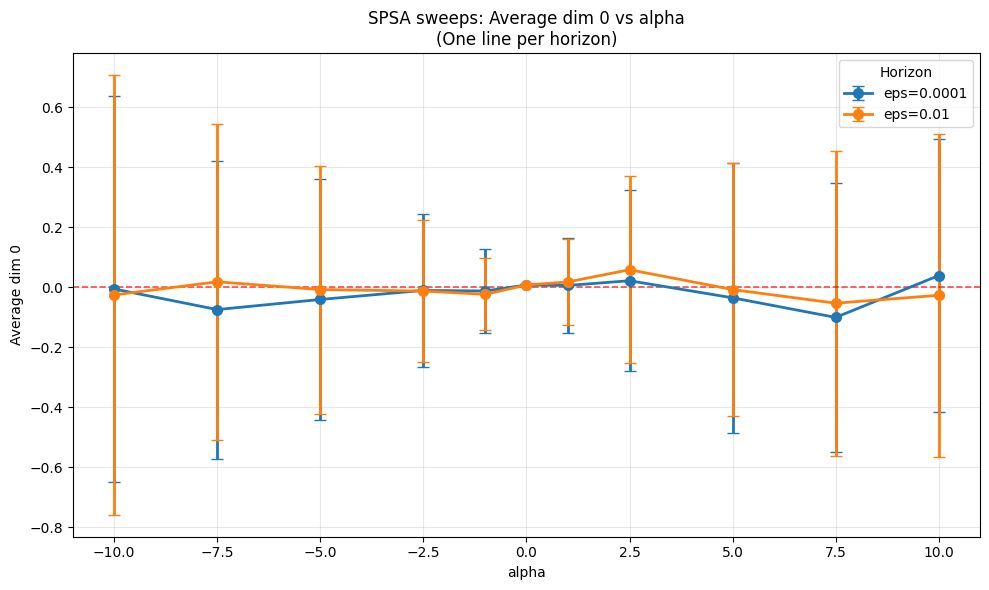

In [39]:
# Filter for SPSA (we'll assume these runs have config_type == 'directional_addition')
dim = 0

# Only keep columns we need to prevent errors
#cols = ['config_magnitude', 'config_horizon', f'average_dim_{dim}']
data = df_spsa.copy()

# Get all unique horizons sorted
eps = sorted(data['config_eps'].unique(), key=lambda x: float(x))

plt.figure(figsize=(10, 6))

for e in eps:
    subset = data[(data['config_eps'] == e)]
    grouped = subset.groupby('config_magnitude')[f'average_dim_{dim}'].agg(
        ['mean', 'std'])
    x_pos = range(len(grouped))
    plt.errorbar(
        grouped.index,
        grouped['mean'],
        yerr=grouped['std'],
        fmt='-o',
        markersize=7,
        label=f'eps={e}',
        capsize=4,
        linewidth=2,
    )

plt.axhline(y=0, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
plt.xlabel('alpha')
plt.ylabel('Average dim 0')
plt.title('SPSA sweeps: Average dim 0 vs alpha\n(One line per horizon)')
plt.legend(title='Horizon')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


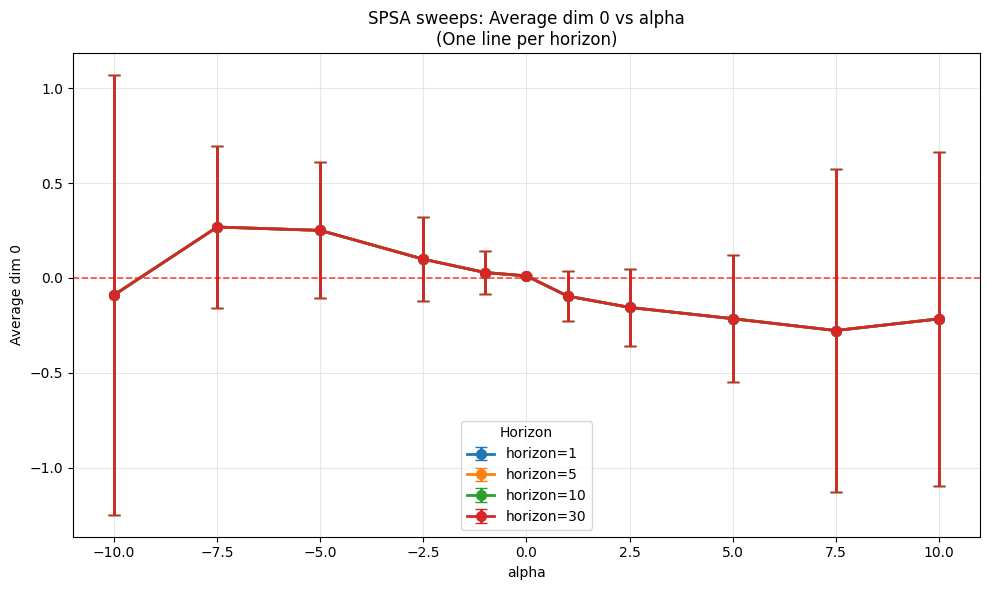

In [89]:
# Analyze only SPSA sweeps, only for dim 0, and plot one line per horizon.

import matplotlib.pyplot as plt

# Filter for SPSA (we'll assume these runs have config_type == 'directional_addition')
dim = 0

# Only keep columns we need to prevent errors
#cols = ['config_magnitude', 'config_horizon', f'average_dim_{dim}']
data = df_spsa.copy()

# Convert config_horizon to str for legend clarity (if it's not already)
data['config_horizon'] = data['config_horizon'].astype(str)

# Get all unique horizons sorted
horizons = sorted(data['config_horizon'].unique(), key=lambda x: float(x))

plt.figure(figsize=(10, 6))
var = 'total_position_change'
#var = 'cumulative_position_change'
for h in horizons:
    subset = data[(data['config_horizon'] == '5') &
                  (data['config_eps'] == 1e-2)]
    grouped = subset.groupby('config_magnitude')[var].agg(['mean', 'std'])
    x_pos = range(len(grouped))
    plt.errorbar(
        grouped.index,
        grouped['mean'],
        yerr=grouped['std'],
        fmt='-o',
        markersize=7,
        label=f'horizon={h}',
        capsize=4,
        linewidth=2,
    )

plt.axhline(y=0, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
plt.xlabel('alpha')
plt.ylabel('Average dim 0')
plt.title('SPSA sweeps: Average dim 0 vs alpha\n(One line per horizon)')
plt.legend(title='Horizon')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
